# Global Mean Surface Temperature

This notebook uses similar techniques to `ECS_Gregory_method.ipynb`. Please refer to that notebook for details.

In [1]:
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import dask
from dask.diagnostics import progress
from tqdm.autonotebook import tqdm 
import intake
import fsspec
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina' 

/tmp/ipykernel_85654/2391262215.py:6: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [4]:
import intake
import pandas as pd
import intake_esm.cat

# Monkeypatch the method to use applymap()
def _columns_with_iterables(self):
    if self._df.empty:
        return set()
    has_iterables = (
        self._df.sample(20, replace=True).applymap(type)
        .isin([list, tuple, set])
        .any()
        .to_dict()
    )
    return {column for column, check in has_iterables.items() if check}

intake_esm.cat.ESMCatalogModel.columns_with_iterables = property(_columns_with_iterables)

In [5]:
col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
col

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,60


In [6]:
[eid for eid in col.df['experiment_id'].unique() if 'ssp' in eid]

['ssp585',
 'ssp245',
 'ssp370SST-lowCH4',
 'ssp370-lowNTCF',
 'ssp370SST-lowNTCF',
 'ssp370SST-ssp126Lu',
 'ssp370SST',
 'ssp370pdSST',
 'ssp119',
 'ssp370',
 'esm-ssp585-ssp126Lu',
 'ssp126-ssp370Lu',
 'ssp370-ssp126Lu',
 'ssp126',
 'esm-ssp585',
 'ssp245-GHG',
 'ssp245-nat',
 'ssp460',
 'ssp434',
 'ssp534-over',
 'ssp245-stratO3',
 'ssp245-aer',
 'ssp245-cov-modgreen',
 'ssp245-cov-fossil',
 'ssp245-cov-strgreen',
 'ssp245-covid',
 'ssp585-bgc']

In [45]:
#[sid for sid in col.df['source_id'].unique()]

# all models in catalog

In [37]:
# there is currently a significant amount of data for these runs
expts = ['historical', 'ssp126', 'ssp245','ssp370', 'ssp585']



query = dict(
    experiment_id=expts,
    table_id='Amon',            # choose to look at atmospheric variables (A) saved at monthly resolution (mon)               
    variable_id=['tas'],        # choose to look at near-surface air temperature (tas) as our variable
    #member_id = 'r1i1p1f1',     # pick one realization for each model (i.e. just one set of initial conditions)                   
)

col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[
    ["experiment_id", "variable_id", "table_id", "member_id"]
].nunique()

,experiment_id,variable_id,table_id,member_id
source_id,,,,
ACCESS-CM2,5,1,1,5
ACCESS-ESM1-5,5,1,1,40
AWI-CM-1-1-MR,5,1,1,5
BCC-CSM2-MR,5,1,1,3
CAMS-CSM1-0,5,1,1,3
CAS-ESM2-0,5,1,1,4
CESM2,5,1,1,11
CESM2-WACCM,5,1,1,5
CMCC-CM2-SR5,5,1,1,3


In [82]:
# pick only models you want

expts = ['historical', 'ssp126', 'ssp245','ssp370', 'ssp585']
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'MPI-ESM1-2-HR', 'MRI-ESM2-0'] # NOTE! In settings is EC-EARTH
# CNRM-ESM2-1 is r1i1p1f2, others are r1i1p1f1


query = dict(
    experiment_id=expts,
    table_id='Amon',            # choose to look at atmospheric variables (A) saved at monthly resolution (mon)               
    variable_id=['tas'],        # choose to look at near-surface air temperature (tas) as our variable
    #member_id = 'r1i1p1f1',     # pick one realization for each model (i.e. just one set of initial conditions)
    source_id = GCMs,           # select models you want 
              
)

col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[
    ["experiment_id", "variable_id", "table_id","member_id"]
].nunique()

,experiment_id,variable_id,table_id,member_id
source_id,,,,
ACCESS-CM2,5,1,1,5
CNRM-ESM2-1,5,1,1,11
CanESM5,5,1,1,65
EC-Earth3,5,1,1,98
MPI-ESM1-2-HR,5,1,1,10
MRI-ESM2-0,5,1,1,16


## To do:

Do this with a dictionary actually ! 

In [192]:
valid_members = ['r1i1p1f1', 'r1i1p1f2']

df = col_subset.df[col_subset.df["member_id"].isin(valid_members)].copy()

# ensure r1i1p1f1 is preferred over r1i1p1f2
df["member_id"] = pd.Categorical(df["member_id"], categories=valid_members, ordered=True)

# sort so r1i1p1f1 comes first within each group
df = df.sort_values(["source_id", "experiment_id", "member_id"])

# drop duplicates keeping the first (i.e. r1i1p1f1 if available)
df = df.drop_duplicates(subset=["source_id", "experiment_id"], keep="first")

# optional: check result
df.groupby("source_id")[["experiment_id", "member_id"]].nunique()

,experiment_id,member_id
source_id,,
ACCESS-CM2,5,1
CNRM-ESM2-1,5,1
CanESM5,5,1
EC-Earth3,5,1
MPI-ESM1-2-HR,5,1
MRI-ESM2-0,5,1


In [193]:
# update catalog with this  

col_subset.esmcat._df = df
col_subset

,unique
activity_id,2
institution_id,7
source_id,6
experiment_id,5
member_id,2
table_id,1
variable_id,1
grid_label,2
zstore,30
dcpp_init_year,0


In [194]:
df

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
1,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/...,NaN,20191108
14,ScenarioMIP,CSIRO-ARCCSS,ACCESS-CM2,ssp126,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCE...,NaN,20210317
0,ScenarioMIP,CSIRO-ARCCSS,ACCESS-CM2,ssp245,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCE...,NaN,20191108
2,ScenarioMIP,CSIRO-ARCCSS,ACCESS-CM2,ssp370,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCE...,NaN,20191108
13,ScenarioMIP,CSIRO-ARCCSS,ACCESS-CM2,ssp585,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCE...,NaN,20210317
25,CMIP,CNRM-CERFACS,CNRM-ESM2-1,historical,r1i1p1f2,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1...,NaN,20181206
31,ScenarioMIP,CNRM-CERFACS,CNRM-ESM2-1,ssp126,r1i1p1f2,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM...,NaN,20190328
30,ScenarioMIP,CNRM-CERFACS,CNRM-ESM2-1,ssp245,r1i1p1f2,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM...,NaN,20190328
48,ScenarioMIP,CNRM-CERFACS,CNRM-ESM2-1,ssp370,r1i1p1f2,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM...,NaN,20191021
49,ScenarioMIP,CNRM-CERFACS,CNRM-ESM2-1,ssp585,r1i1p1f2,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM...,NaN,20191021


In [195]:
def drop_all_bounds(ds):
    """Drop coordinates like 'time_bounds' from datasets,
    which can lead to issues when merging."""
    drop_vars = [vname for vname in ds.coords
                 if (('_bounds') in vname ) or ('_bnds') in vname]
    return ds.drop(drop_vars)

def open_dset(df):
    """Open datasets from cloud storage and return xarray dataset."""
    assert len(df) == 1
    ds = xr.open_zarr(fsspec.get_mapper(df.zstore.values[0]), consolidated=True)
    return drop_all_bounds(ds)

def open_delayed(df):
    """A dask.delayed wrapper around `open_dsets`.
    Allows us to open many datasets in parallel."""
    return dask.delayed(open_dset)(df)



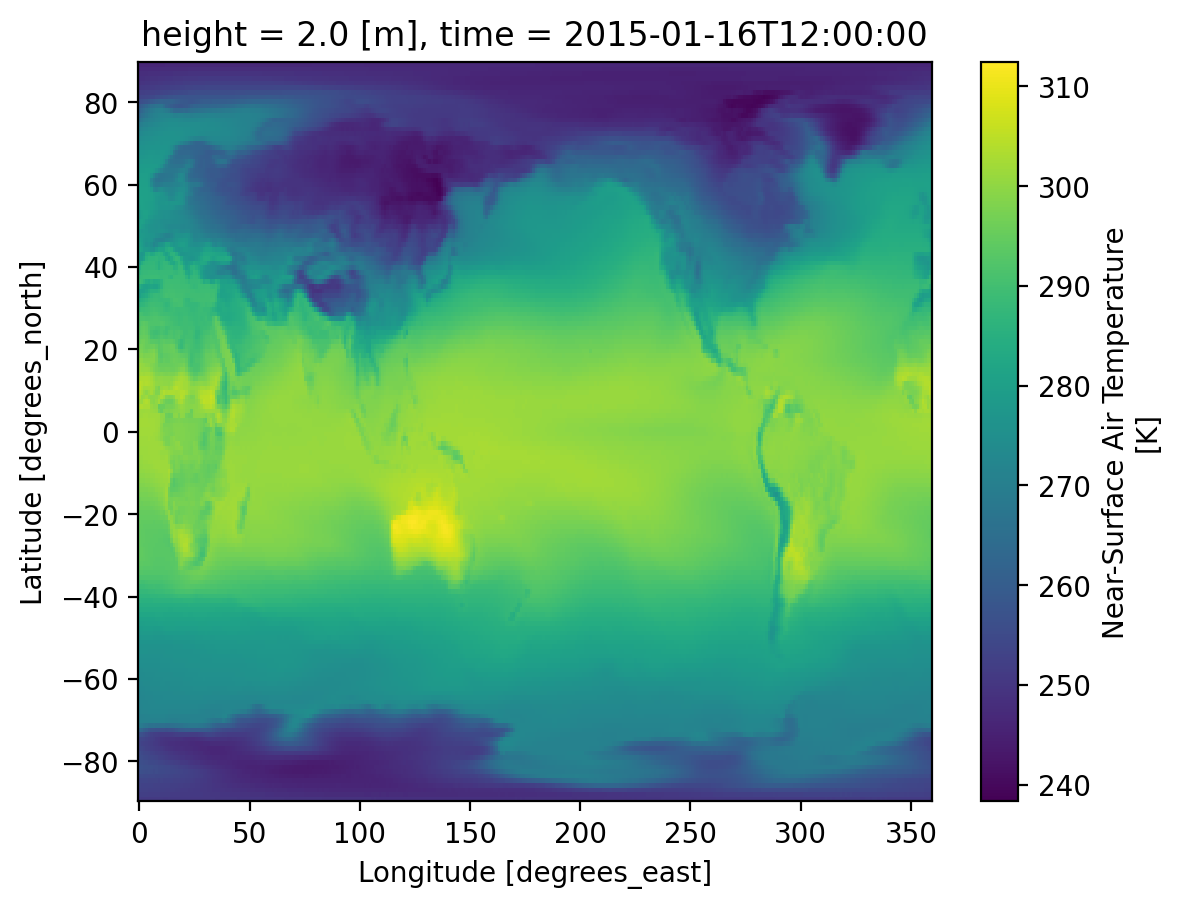

In [ ]:
df_sel = col_subset.df[(col_subset.df['source_id'] == 'MRI-ESM2-0') & (col_subset.df['experiment_id'] == 'ssp245')]
ds_test = open_dset(df_sel)
ds_test.isel(time=0)['tas'].plot()

# figure out what's wrong with MRI ssp245 - it looks fine!

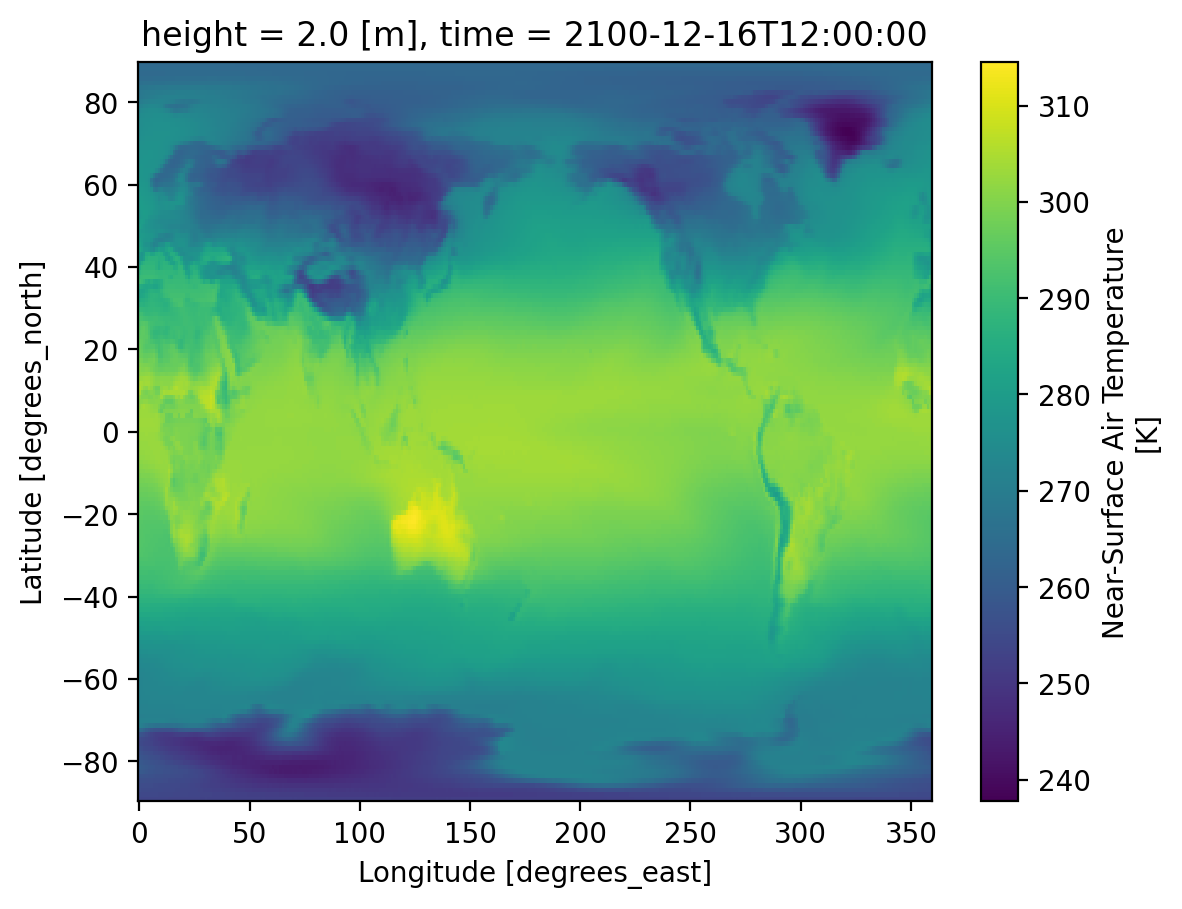

In [157]:
ds_test.isel(time=-1)['tas'].plot()

In [156]:
ds_test

<xarray.Dataset>
Dimensions:  (lat: 160, lon: 320, time: 1032)
Coordinates:
    height   float64 ...
  * lat      (lat) float64 -89.14 -88.03 -86.91 -85.79 ... 86.91 88.03 89.14
  * lon      (lon) float64 0.0 1.125 2.25 3.375 4.5 ... 355.5 356.6 357.8 358.9
  * time     (time) datetime64[ns] 2015-01-16T12:00:00 ... 2100-12-16T12:00:00
Data variables:
    tas      (time, lat, lon) float32 dask.array<chunksize=(600, 160, 320), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    cmor_version:           3.4.0
    ...                     ...
    tracking_id:            hdl:21.14100/b5ee04a0-866f-4db0-a094-aff1bac6ab93
    variable_id:            tas
    variant_label:          r1i1p1f1
    status:                 2019-10-25;created;by nhn2@columbia.edu
    netcdf_tracking_ids:    hdl:21.14100/b5ee04a0-866f-4db0-a094-aff1bac6ab93
    version_id:             v20190222

Create a nested dictionary of models and experiments. It will be structured like this:

    {'CESM2':
      {
        'piControl': <xarray.Dataset>,
        'abrupt-4xCO2': <xarray.Dataset>
      },
      ...
    }

In [ ]:
from collections import defaultdict
dsets = defaultdict(dict) 
#dsets = defaultdict(lambda: defaultdict(dict))

for group, df in col_subset.df.groupby(by=['source_id', 'experiment_id',"member_id"]):

    #dsets[group[0]][group[1]][group[2]] = open_delayed(df)
    dsets[group[0]][group[1]] = open_delayed(df)

In [235]:
# trying to have also ens member! 

from collections import defaultdict
#dsets = defaultdict(dict) 
dsets = defaultdict(lambda: defaultdict(dict))

for group, df in col_subset.df.groupby(by=['source_id', 'experiment_id',"member_id"]):

    dsets[group[0]][group[1]][group[2]] = open_delayed(df)
    #dsets[group[0]][group[1]] = open_delayed(df)

In [237]:
dsets_ = dask.compute(dict(dsets))[0]

In [238]:
dsets_

{'ACCESS-CM2': defaultdict(dict,
             {'historical': {'r1i1p1f1': Delayed('open_dset-252b6fd8-3f4c-43f5-9ddc-3c44835a13c6')},
              'ssp126': {'r1i1p1f1': Delayed('open_dset-dbd58e60-0481-441d-98a4-3d989320aec9')},
              'ssp245': {'r1i1p1f1': Delayed('open_dset-98011e01-9d01-4ec0-976a-4741e05013eb')},
              'ssp370': {'r1i1p1f1': Delayed('open_dset-48a4a274-1ef3-46cd-86a6-67d95aa10d44')},
              'ssp585': {'r1i1p1f1': Delayed('open_dset-28d7754a-df6c-4834-8a9c-b6bca69d1154')}}),
 'CNRM-ESM2-1': defaultdict(dict,
             {'historical': {'r1i1p1f2': Delayed('open_dset-1ee7a938-42be-45a0-827f-c57163274ddb')},
              'ssp126': {'r1i1p1f2': Delayed('open_dset-39ac8de0-22dc-4b27-9f17-2c8548651e5b')},
              'ssp245': {'r1i1p1f2': Delayed('open_dset-28476460-4eb1-444f-91eb-5124b54c0918')},
              'ssp370': {'r1i1p1f2': Delayed('open_dset-1e0316d3-19ba-45e5-ba82-40be141b39ce')},
              'ssp585': {'r1i1p1f2': Delayed('open

In [230]:
# calculate global means

def get_lat_name(ds):
    """Figure out what is the latitude coordinate for each dataset."""

    for lat_name in ['lat', 'latitude']:
        if lat_name in ds.coords:
            return lat_name
    raise RuntimeError("Couldn't find a latitude coordinate")

def global_mean(ds):
    """Return global mean of a whole dataset."""

    lat = ds[get_lat_name(ds)]
    weight = np.cos(np.deg2rad(lat))
    weight /= weight.mean()
    other_dims = set(ds.dims) - {'time'}
    return (ds * weight).mean(other_dims,skipna=True)

In [ ]:
expt_da = xr.DataArray(expts, dims='experiment_id', name='experiment_id',
                       coords={'experiment_id': expts})

dsets_aligned = {}

for k, v in tqdm(dsets_.items()):
    print(k)
    print(v)
    expt_dsets = v.values()
    if any([d is None for d in expt_dsets]):
        print(f"Missing experiment for {k}")
        continue
    
    for ds in expt_dsets:
        ds.coords['year'] = ds.time.dt.year
        print(ds.experiment_id)
        print(ds.time.dt.year.values[0],ds.time.dt.year.values[-1])
        
        
    # workaround for
    # https://github.com/pydata/xarray/issues/2237#issuecomment-620961663
    dsets_ann_mean = [v[expt].pipe(global_mean)
                             .swap_dims({'time': 'year'})
                             .drop('time')
                             .coarsen(year=12).mean(skipna=True)
                      for expt in expts]
    
    # align everything 
    dsets_aligned[k] = xr.concat(dsets_ann_mean, join='outer',
                                 dim=expt_da)

  0%|          | 0/6 [00:00<?, ?it/s]

ACCESS-CM2
defaultdict(<class 'dict'>, {'historical': {'r1i1p1f1': Delayed('open_dset-252b6fd8-3f4c-43f5-9ddc-3c44835a13c6')}, 'ssp126': {'r1i1p1f1': Delayed('open_dset-dbd58e60-0481-441d-98a4-3d989320aec9')}, 'ssp245': {'r1i1p1f1': Delayed('open_dset-98011e01-9d01-4ec0-976a-4741e05013eb')}, 'ssp370': {'r1i1p1f1': Delayed('open_dset-48a4a274-1ef3-46cd-86a6-67d95aa10d44')}, 'ssp585': {'r1i1p1f1': Delayed('open_dset-28d7754a-df6c-4834-8a9c-b6bca69d1154')}})


AttributeError: 'dict' object has no attribute 'time'

In [ ]:
expt_da = xr.DataArray(expts, dims='experiment_id', name='experiment_id',
                       coords={'experiment_id': expts})

dsets_aligned = {}

for k, v in tqdm(dsets_.items()):
    print(k)
    print(v)
    expt_dsets = v.values()
    if any([d is None for d in expt_dsets]):
        print(f"Missing experiment for {k}")
        continue
    
    for ds in expt_dsets:
        ds.coords['year'] = ds.time.dt.year
        print(ds.experiment_id)
        print(ds.time.dt.year.values[0],ds.time.dt.year.values[-1])
        
        
    # workaround for
    # https://github.com/pydata/xarray/issues/2237#issuecomment-620961663
    dsets_ann_mean = [v[expt].pipe(global_mean)
                             .swap_dims({'time': 'year'})
                             .drop('time')
                             .coarsen(year=12).mean(skipna=True)
                      for expt in expts]
    
    # align everything 
    dsets_aligned[k] = xr.concat(dsets_ann_mean, join='outer',
                                 dim=expt_da)

In [201]:
with progress.ProgressBar():
    dsets_aligned_ = dask.compute(dsets_aligned)[0]

[########################################] | 100% Completed | 259.23 s


In [207]:
source_ids = list(dsets_aligned_.keys())
source_da = xr.DataArray(source_ids, dims='source_id', name='source_id',
                         coords={'source_id': source_ids})

big_ds = xr.concat([ds.reset_coords(drop=True)
                    for ds in dsets_aligned_.values()],
                    dim=source_da).sel(year=slice(1850, 2100))

big_ds

<xarray.Dataset>
Dimensions:        (year: 251, experiment_id: 5, source_id: 6)
Coordinates:
  * year           (year) float64 1.85e+03 1.851e+03 ... 2.099e+03 2.1e+03
  * experiment_id  (experiment_id) <U10 'historical' 'ssp126' ... 'ssp585'
  * source_id      (source_id) <U13 'ACCESS-CM2' 'CNRM-ESM2-1' ... 'MRI-ESM2-0'
Data variables:
    tas            (source_id, experiment_id, year) float64 287.0 ... 291.8

In [208]:
big_ds.sel(source_id='EC-Earth3',experiment_id='ssp245')['tas']

<xarray.DataArray 'tas' (year: 251)>
array([         nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
...
       288.53781197, 288.66346635, 288.71786229, 288.79672539,
       288.78662562, 288.76171948, 288.81434863, 288.92009728,
       288.7660738 , 288.73897467, 288.84267262, 288.8490208 ,
       288.85924583, 289.02260475, 288.77753657, 288.70474001,
       288.83416456, 288.98540875, 288.92849858, 289.04789536,
       289.0897399 , 288.924382  , 288.90797737, 289.04860488,
       289.20055217, 289.25674926, 289.09767887, 289.33086747,
       289.62851509, 289.46071407, 289.32838307, 289.41814186,
       289.59695686, 289.45423847, 289.52479722, 289.62095309,
       289.45180416, 289.62398414, 289.84144946, 289.62338372,
       289.70349481, 289.86846862, 289.78312994, 289.76788621,
       289.86824395, 289.73102438, 289.77316423, 289.68672174,
       289.82650133, 289.88365429, 289.88498511, 290.00593997,
       290.07109359, 289.7752536 , 289.90660509, 290.05649939,
       289.89967101, 289.99812347, 290.15352024, 289.97209771,
       289.90949401, 289.79151376, 289.85787413, 290.10783309,
       290.31724162, 290.13761858, 290.19777478, 290.19767043,
       290.21706645, 290.21501721, 290.2591968 , 290.49566797,
       290.31880532, 290.28007119, 290.60848542, 290.25636521,
       290.32148427, 290.46535464, 290.43041504])
Coordinates:
  * year           (year) float64 1.85e+03 1.851e+03 ... 2.099e+03 2.1e+03
    experiment_id  <U10 'ssp245'
    source_id      <U13 'EC-Earth3'

In [210]:
df_all = big_ds.sel(year=slice(1850, 2100)).to_dataframe().reset_index()
df_all

,year,experiment_id,source_id,tas
0,1850.0,historical,ACCESS-CM2,287.007494
1,1850.0,historical,CNRM-ESM2-1,286.900465
2,1850.0,historical,CanESM5,286.806542
3,1850.0,historical,EC-Earth3,287.029662
4,1850.0,historical,MPI-ESM1-2-HR,287.064616
...,...,...,...,...
7525,2100.0,ssp585,CNRM-ESM2-1,292.475368
7526,2100.0,ssp585,CanESM5,294.452385
7527,2100.0,ssp585,EC-Earth3,293.272894
7528,2100.0,ssp585,MPI-ESM1-2-HR,291.375668


In [211]:
df_all.tail(50)

,year,experiment_id,source_id,tas
7480,2099.0,ssp126,MPI-ESM1-2-HR,288.557125
7481,2099.0,ssp126,MRI-ESM2-0,288.525146
7482,2099.0,ssp245,ACCESS-CM2,290.489873
7483,2099.0,ssp245,CNRM-ESM2-1,289.993189
7484,2099.0,ssp245,CanESM5,291.026021
7485,2099.0,ssp245,EC-Earth3,290.465355
7486,2099.0,ssp245,MPI-ESM1-2-HR,289.385467
7487,2099.0,ssp245,MRI-ESM2-0,289.497384
7488,2099.0,ssp370,ACCESS-CM2,291.910892
7489,2099.0,ssp370,CNRM-ESM2-1,291.322063


/apps/brussel/RL8/zen4/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


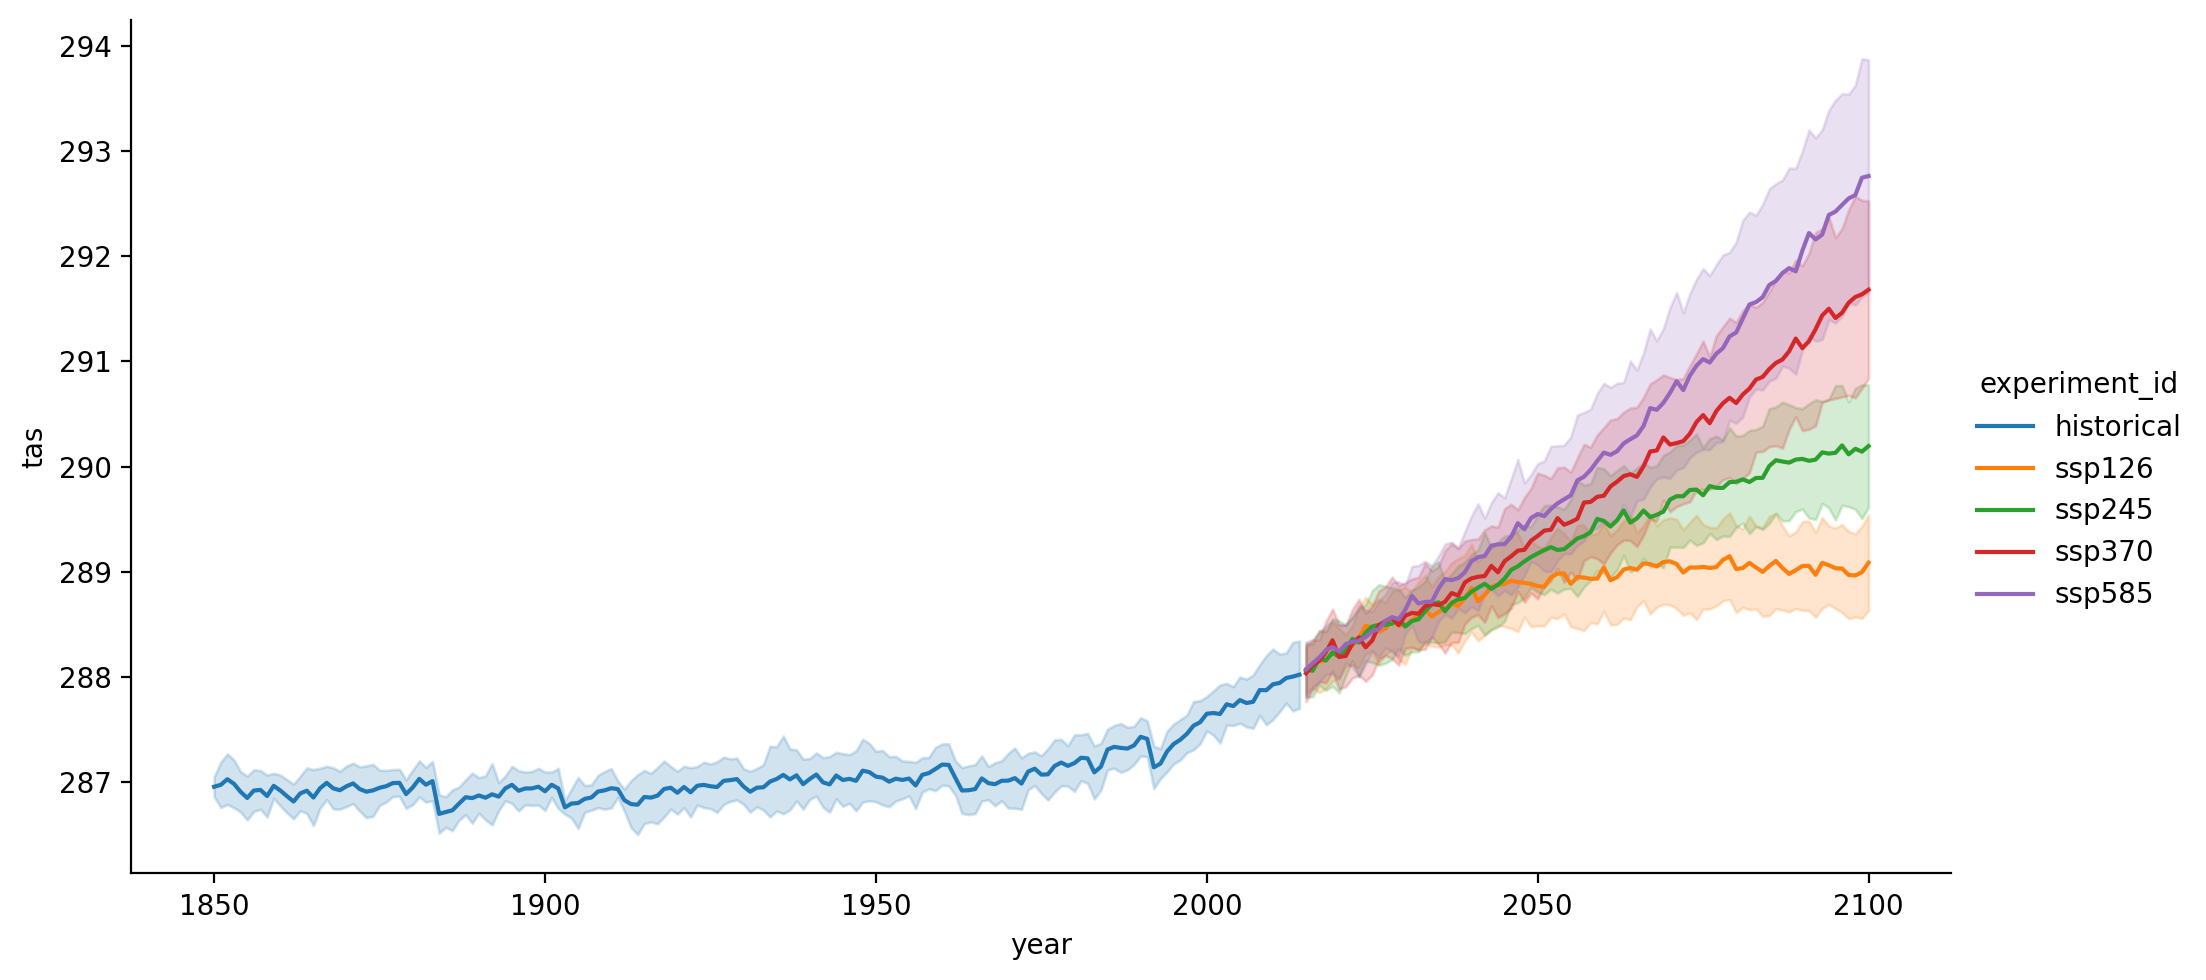

In [212]:
sns.relplot(data=df_all,
            x="year", y="tas", hue='experiment_id',
            kind="line", errorbar="sd", aspect=2);

In [ ]:
#df_all.to_csv('../data/gmst-models/gmst_models_1850_2100_fwi.csv')

## repeat for all available models from Pangeo? To have as input data of dem4cli

In [ ]:

def load_model_gmst(experiments=scenarios,
                    GCMs=GCMs,
                    first_ens_member=True,
                    startyear=1850,
                    endyear=2100
    ):

    from tqdm.autonotebook import tqdm 
    import intake
    import fsspec
    import intake_esm.cat
    from collections import defaultdict

    # Monkeypatch the method to use applymap()
    def _columns_with_iterables(self):
        if self._df.empty:
            return set()
        has_iterables = (
            self._df.sample(20, replace=True).applymap(type)
            .isin([list, tuple, set])
            .any()
            .to_dict()
        )
        return {column for column, check in has_iterables.items() if check}

    def drop_all_bounds(ds):
        """Drop coordinates like 'time_bounds' from datasets,
        which can lead to issues when merging."""
        drop_vars = [vname for vname in ds.coords
                    if (('_bounds') in vname ) or ('_bnds') in vname]
        return ds.drop(drop_vars)

    def open_dset(df):
        """Open datasets from cloud storage and return xarray dataset."""
        assert len(df) == 1
        ds = xr.open_zarr(fsspec.get_mapper(df.zstore.values[0]), consolidated=True)
        return drop_all_bounds(ds)

    def open_delayed(df):
        """A dask.delayed wrapper around `open_dsets`.
        Allows us to open many datasets in parallel."""
        return dask.delayed(open_dset)(df)

    def get_lat_name(ds):
        """Figure out what is the latitude coordinate for each dataset."""
        for lat_name in ['lat', 'latitude']:
            if lat_name in ds.coords:
                return lat_name
        raise RuntimeError("Couldn't find a latitude coordinate")

    def global_mean(ds):
        """Return global mean of a whole dataset."""

        lat = ds[get_lat_name(ds)]
        weight = np.cos(np.deg2rad(lat))
        weight /= weight.mean()
        other_dims = set(ds.dims) - {'time'}
        return (ds * weight).mean(other_dims,skipna=True)

    intake_esm.cat.ESMCatalogModel.columns_with_iterables = property(_columns_with_iterables)

    # open catalogue from Pangeo 
    col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")

    if GCMs:
        query = dict(
        experiment_id=expts,
        table_id='Amon',            # choose to look at atmospheric variables (A) saved at monthly resolution (mon)               
        variable_id=['tas'],        # choose to look at near-surface air temperature (tas) as our variable
        source_id = GCMs
        )
    else:
        query = dict(
        experiment_id=expts,
        table_id='Amon',            # choose to look at atmospheric variables (A) saved at monthly resolution (mon)               
        variable_id=['tas'],        # choose to look at near-surface air temperature (tas) as our variable
        )

    col_subset = col.search(require_all_on=["source_id"], **query)

    if first_ens_member:
        df = col_subset.df.copy()

        # Sort by member_id to ensure stable, deterministic order (optional)
        df = df.sort_values(["source_id", "experiment_id", "member_id"])

        # Drop duplicates — keep the first ensemble member per model & experiment
        df = df.drop_duplicates(subset=["source_id", "experiment_id"], keep="first")

        # optional: check result
        print(df.groupby("source_id")[["experiment_id", "member_id"]].nunique())

        # update catalog with this  
        col_subset.esmcat._df = df
        col_subset

    dsets = defaultdict(dict) 

    for group, df in col_subset.df.groupby(by=['source_id', 'experiment_id',"member_id"]):
        dsets[group[0]][group[1]] = open_delayed(df)

    dsets_ = dask.compute(dict(dsets))[0]

    expt_da = xr.DataArray(expts, dims='experiment_id', name='experiment_id',
                       coords={'experiment_id': expts})

    dsets_aligned = {}

    for k, v in tqdm(dsets_.items()):
        print(k)
        expt_dsets = v.values()
        if any([d is None for d in expt_dsets]):
            print(f"Missing experiment for {k}")
            continue
        
        for ds in expt_dsets:
            ds.coords['year'] = ds.time.dt.year
            print(ds.experiment_id)
            print(ds.time.dt.year.values[0],ds.time.dt.year.values[-1])
            
        # workaround for
        # https://github.com/pydata/xarray/issues/2237#issuecomment-620961663
        dsets_ann_mean = [v[expt].pipe(global_mean)
                                .swap_dims({'time': 'year'})
                                .drop('time')
                                .coarsen(year=12).mean(skipna=True)
                        for expt in expts]
        
        # align everything 
        dsets_aligned[k] = xr.concat(dsets_ann_mean, join='outer',
                                    dim=expt_da)
    
    with progress.ProgressBar():
        dsets_aligned_ = dask.compute(dsets_aligned)[0]
    
    source_ids = list(dsets_aligned_.keys())

    source_da = xr.DataArray(source_ids, dims='source_id', name='source_id',
                            coords={'source_id': source_ids})

    big_ds = xr.concat([ds.reset_coords(drop=True)
                        for ds in dsets_aligned_.values()],
                        dim=source_da)

    df_gmst_all = big_ds.sel(year=slice(startyear, endyear)).to_dataframe().reset_index()

    return df_gmst_all

In [219]:
df_gmst_all = load_model_gmst(experiments=scenarios,
                    GCMs=None,
                    first_ens_member=True,
                    startyear=1850,
                    endyear=2100)

                  experiment_id  member_id
source_id                                 
ACCESS-CM2                    5          1
ACCESS-ESM1-5                 3          1
AWI-CM-1-1-MR                 5          1
BCC-CSM2-MR                   5          1
CAMS-CSM1-0                   5          1
CAS-ESM2-0                    5          1
CESM2                         1          1
CESM2-WACCM                   5          1
CMCC-CM2-SR5                  5          1
CMCC-ESM2                     5          1
CNRM-CM6-1                    5          1
CNRM-CM6-1-HR                 5          1
CNRM-ESM2-1                   5          1
CanESM5                       5          1
EC-Earth3                     5          1
EC-Earth3-Veg                 5          1
EC-Earth3-Veg-LR              5          1
FGOALS-f3-L                   5          1
FGOALS-g3                     5          1
GFDL-ESM4                     5          1
GISS-E2-1-G                   1          1
GISS-E2-1-H

  0%|          | 0/37 [00:00<?, ?it/s]

ACCESS-CM2
historical
1850 2014
ssp126
2015 2300
ssp245
2015 2100
ssp370
2015 2100
ssp585
2015 2300


  3%|▎         | 1/37 [00:01<00:58,  1.63s/it]

ACCESS-ESM1-5
historical
1850 2014
ssp126
2015 2300
ssp585
2015 2300


  3%|▎         | 1/37 [00:02<01:27,  2.42s/it]


KeyError: 'ssp245'